# 04 · ML: predicting bad reviews at delivery time

**Business question:** when an order is delivered, can we flag which ones will receive a 1-2 star review, so customer service can act first?

**Design choices**
- Only features known at delivery time (no data leakage).
- Temporal split: train before 2018-05-01, test from 2018-05-01 onward.
- Class imbalance handled with `class_weight="balanced"`; main metric = PR-AUC.
- Preprocessing inside a scikit-learn `Pipeline`; experiments tracked with MLflow.

In [0]:
%pip install seaborn scikit-learn mlflow --quiet

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
%sql
-- Feature table: one row per delivered order with a review
CREATE OR REPLACE TABLE workspace.gold.ml_features_bad_review AS
WITH item_main AS (          -- category and seller of the most expensive item in the order
  SELECT s.order_id,
         max_by(p.category, s.price)  AS main_category,
         max_by(s.seller_id, s.price) AS main_seller_id
  FROM workspace.gold.fact_sales s
  JOIN workspace.gold.dim_product p ON s.product_id = p.product_id
  GROUP BY s.order_id
)
SELECT o.order_id,
       o.date_key,
       o.order_value, o.freight_value,
       round(o.freight_value / nullif(o.order_value, 0), 3)        AS freight_ratio,
       o.items_qty, o.sellers_qty, o.max_installments, o.main_payment_type,
       datediff(so.estimated_delivery_ts, so.purchase_ts)          AS promised_days,
       o.delivery_days, o.delivery_delay_days,
       i.main_category,
       cu.state AS customer_state, sl.state AS seller_state,
       CAST(cu.state = sl.state AS INT)                            AS same_state,
       round(2 * 6371 * asin(sqrt(
             pow(sin(radians(sl.lat - gc.lat) / 2), 2) +
             cos(radians(gc.lat)) * cos(radians(sl.lat)) *
             pow(sin(radians(sl.lng - gc.lng) / 2), 2))), 1)       AS distance_km,
       CAST(o.is_bad_review AS INT)                                AS label
FROM workspace.gold.fact_orders o
JOIN workspace.silver.orders so    ON o.order_id = so.order_id
JOIN workspace.silver.customers cu ON so.customer_id = cu.customer_id   -- address of THIS order (no leakage)
LEFT JOIN workspace.silver.geolocation gc ON cu.zip_prefix = gc.zip_prefix
JOIN item_main i                   ON o.order_id = i.order_id
JOIN workspace.gold.dim_seller sl  ON i.main_seller_id = sl.seller_id
WHERE o.order_status = 'delivered'
  AND o.review_score IS NOT NULL
  AND o.delivery_days IS NOT NULL;

num_affected_rows,num_inserted_rows


(95824, 18)
Bad review rate: 12.8%


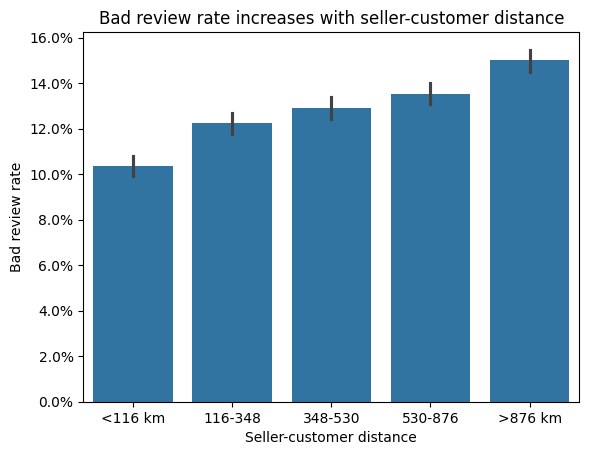

In [0]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

df = spark.table("workspace.gold.ml_features_bad_review").toPandas()
df["date_key"] = pd.to_datetime(df["date_key"])

print(df.shape)
print(f"Bad review rate: {df['label'].mean():.1%}")

# Bad review rate by seller-customer distance (5 equal-size groups)
df["distance_bucket"] = pd.qcut(df["distance_km"], 5)
labels = ["<116 km", "116-348", "348-530", "530-876", ">876 km"]
ax = sns.barplot(data=df, x="distance_bucket", y="label")
ax.set_xticks(range(len(labels)), labels)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set(xlabel="Seller-customer distance", ylabel="Bad review rate",
       title="Bad review rate increases with seller-customer distance")
plt.show()

In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ["order_value", "freight_value", "freight_ratio", "items_qty", "sellers_qty",
            "max_installments", "promised_days", "delivery_days", "delivery_delay_days",
            "same_state", "distance_km"]
cat_cols = ["main_payment_type", "main_category", "customer_state", "seller_state"]
features = num_cols + cat_cols

cutoff = "2018-05-01"                          # train on the past, evaluate on the future
train, test = df[df.date_key < cutoff], df[df.date_key >= cutoff]
X_train, y_train = train[features], train["label"]
X_test,  y_test  = test[features],  test["label"]
print(f"train: {len(train):,} | test: {len(test):,}")

preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore",
                                            min_frequency=50, sparse_output=False))]), cat_cols),
])

train: 70,582 | test: 25,242


In [0]:
import mlflow
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, precision_score


user = spark.sql("SELECT current_user()").first()[0]
mlflow.set_experiment(f"/Users/{user}/olist_bad_reviews")

mlflow.sklearn.autolog(log_models=True)

def evaluate(pipe, threshold=0.5):
    """Test metrics for a fitted pipeline at a given decision threshold."""
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {"test_roc_auc":   roc_auc_score(y_test, proba),
            "test_pr_auc":    average_precision_score(y_test, proba),
            "test_recall":    recall_score(y_test, pred),
            "test_precision": precision_score(y_test, pred)}

candidates = {
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "hist_gradient_boosting": HistGradientBoostingClassifier(class_weight="balanced",
                                                             max_iter=300, learning_rate=0.05,
                                                             random_state=42),
}

results = {}
for name, model in candidates.items():
    with mlflow.start_run(run_name=name) as run:
        pipe = Pipeline([("prep", clone(preprocess)), ("model", model)])
        pipe.fit(X_train, y_train)
        metrics = evaluate(pipe)
        mlflow.log_metrics(metrics)
        results[name] = {"pipe": pipe, "run_id": run.info.run_id, **metrics}

pd.DataFrame(results).T.drop(columns="pipe")

2026/10/08 18:32:52 INFO mlflow.tracking.fluent: Experiment with name '/Users/nahuelms325@gmail.com/olist_bad_reviews' does not exist. Creating a new experiment.
If you are using MLflow Tracing, consider storing your traces in Unity Catalog for unlimited storage (no 100,000 trace limit), fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/trace-unity-catalog
2026/10/08 18:32:58 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
🔗 View Logged Model at: https://dbc-cdb0dfbc-3e36.cloud.databricks.com/ml/experiments/1370574837860360/models/m-708b52877d4441a9969ec3b558ae853a?o=7474659102524531
2026/10/08 18:33:20 WARNING mlflow.models.signature: Failed to infer schema for inputs. Set

,run_id,test_roc_auc,test_pr_auc,test_recall,test_precision
logistic_regression,04b93fa5c4274affa5b06361d75404ab,0.692361,0.25862,0.377822,0.278053
hist_gradient_boosting,77a4e580c312493c98dd105b816936cb,0.703242,0.32778,0.42099,0.308205


In [0]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from scipy.stats import loguniform, randint

# Sort train by date so CV folds respect time: train on the past, validate on the future
order = train.sort_values("date_key").index
X_tr, y_tr = X_train.loc[order], y_train.loc[order]
tscv = TimeSeriesSplit(n_splits=3)

mlflow.sklearn.autolog(log_models=True, max_tuning_runs=5)

# --- Random Forest ---
with mlflow.start_run(run_name="random_forest") as run:
    rf = Pipeline([("prep", clone(preprocess)),
                   ("model", RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                                    max_features="sqrt",
                                                    class_weight="balanced_subsample",
                                                    n_jobs=-1, random_state=42))])
    rf.fit(X_tr, y_tr)
    m = evaluate(rf)
    mlflow.log_metrics(m)
    results["random_forest"] = {"pipe": rf, "run_id": run.info.run_id, **m}

# --- Hyperparameter tuning: HistGradientBoosting, temporal CV, optimizing PR-AUC ---
param_dist = {
    "model__learning_rate":     loguniform(0.02, 0.2),
    "model__max_iter":          randint(200, 800),
    "model__max_leaf_nodes":    randint(15, 64),
    "model__min_samples_leaf":  randint(20, 200),
    "model__l2_regularization": loguniform(1e-3, 10),
}
hgb_base = Pipeline([("prep", clone(preprocess)),
                     ("model", HistGradientBoostingClassifier(class_weight="balanced",
                                                              random_state=42))])
search = RandomizedSearchCV(hgb_base, param_dist, n_iter=20, cv=tscv,
                            scoring="average_precision", n_jobs=-1,
                            random_state=42, refit=True, verbose=1)

with mlflow.start_run(run_name="hgb_tuned") as run:
    search.fit(X_tr, y_tr)
    best_hgb = search.best_estimator_
    m = evaluate(best_hgb)
    mlflow.log_metrics({**m, "cv_pr_auc": search.best_score_})
    results["hgb_tuned"] = {"pipe": best_hgb, "run_id": run.info.run_id, **m}

print("Best CV PR-AUC:", round(search.best_score_, 3))
print("Best params:", search.best_params_)

pd.DataFrame(results).T.drop(columns="pipe").sort_values("test_pr_auc", ascending=False)

2026/10/08 18:35:33 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
🔗 View Logged Model at: https://dbc-cdb0dfbc-3e36.cloud.databricks.com/ml/experiments/1370574837860360/models/m-6fe9b9fe175b4f70b558b57b0591c07c?o=7474659102524531


Fitting 3 folds for each of 20 candidates, totalling 60 fits


2026/10/08 18:37:46 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
🔗 View Logged Model at: https://dbc-cdb0dfbc-3e36.cloud.databricks.com/ml/experiments/1370574837860360/models/m-8f91b21f0fb047cca9b811bb0dd9ec82?o=7474659102524531
🔗 View Logged Model at: https://dbc-cdb0dfbc-3e36.cloud.databricks.com/ml/experiments/1370574837860360/models/m-2efb1c3976d145d182235f748c96b16c?o=7474659102524531
2026/10/08 18:38:04 INFO mlflow.sklearn.utils: Logging the 5 best runs, 15 runs will be omitted.


Best CV PR-AUC: 0.52
Best params: {'model__l2_regularization': np.float64(0.017654048052495083), 'model__learning_rate': np.float64(0.06623659776144764), 'model__max_iter': 305, 'model__max_leaf_nodes': 18, 'model__min_samples_leaf': 73}


,run_id,test_roc_auc,test_pr_auc,test_recall,test_precision
hist_gradient_boosting,77a4e580c312493c98dd105b816936cb,0.703242,0.32778,0.42099,0.308205
hgb_tuned,4805417d7c5c4d2d862348834fbfd7e7,0.708424,0.327574,0.42099,0.306605
random_forest,c82c793997024a6498aafaed3aadb20d,0.700415,0.317471,0.407921,0.318787
logistic_regression,04b93fa5c4274affa5b06361d75404ab,0.692361,0.25862,0.377822,0.278053


### Model comparison and tuning
- Three tree-based models (HistGradientBoosting default, tuned, Random Forest) converge at ~0.70 ROC-AUC and ~0.32–0.33 PR-AUC, while logistic regression stays behind (0.26 PR-AUC). The relationship is non-linear, and the current features set the ceiling, not the algorithm.
- Hyperparameter tuning (RandomizedSearchCV, 20 candidates, temporal CV) did not improve test PR-AUC. The default HistGradientBoosting is kept for simplicity.
- Best parameters favor a conservative model (low learning rate, large leaves), consistent with noisy labels.
- CV PR-AUC (0.52) is much higher than test PR-AUC (0.33). The validation folds cover the early-2018 logistics crisis, when bad reviews were mostly delay-driven and easier to predict. This points to a shift in the data over time and the need to monitor and retrain the model.

Final model: hist_gradient_boosting


2026/10/08 18:41:00 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '2ec2d9efc72d47ef82428b96e06936d9', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/10/08 18:41:06 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
🔗 View Logged Model at: https://dbc-cdb0dfbc-3e36.cloud.databricks.com/ml/experiments/1370574837860360/models/m-491c8a1e930144c1934b39018e02dffb?o=7474659102524531


Decision threshold (max F1 on validation): 0.68


test_roc_auc,test_pr_auc,test_recall,test_precision
0.7032421656568967,0.32777961296577435,0.420990099009901,0.30820527689185273
0.7032421656568967,0.32777961296577435,0.2974257425742574,0.45904645476772615


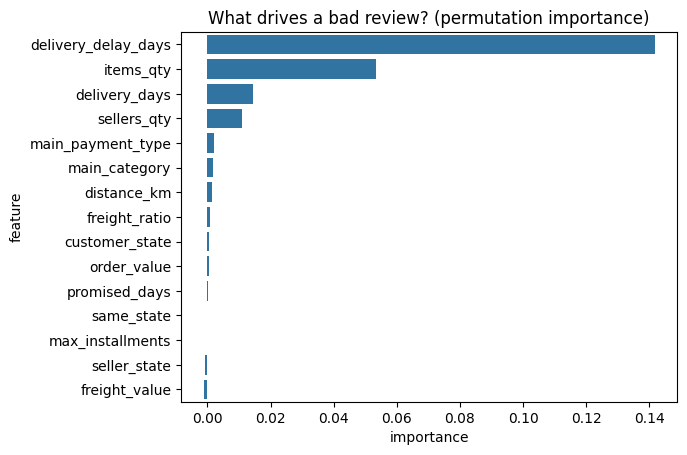

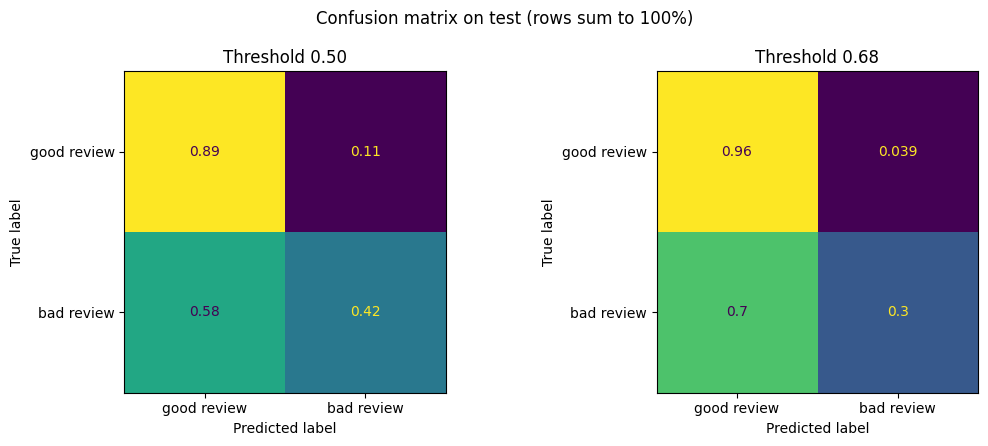

In [0]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve

# 1) Final model: chosen on validation and simplicity, never by looking at test.
#    Tuning did not improve PR-AUC, so we keep the simpler default model.
FINAL_MODEL = "hist_gradient_boosting"
final = results[FINAL_MODEL]["pipe"]
print("Final model:", FINAL_MODEL)

# 2) Decision threshold chosen on validation (most recent 20% of train), not on test
cut = int(len(X_tr) * 0.8)
val_proba = (clone(final).fit(X_tr.iloc[:cut], y_tr.iloc[:cut])
                         .predict_proba(X_tr.iloc[cut:])[:, 1])
prec, rec, thr = precision_recall_curve(y_tr.iloc[cut:], val_proba)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
THRESHOLD = float(thr[np.argmax(f1[:-1])])
print(f"Decision threshold (max F1 on validation): {THRESHOLD:.2f}")
display(pd.DataFrame([evaluate(final, 0.5), evaluate(final, THRESHOLD)],
                     index=["threshold 0.50", f"threshold {THRESHOLD:.2f}"]))

# 3) Feature importance on a test sample (faster, same conclusions)
sample = X_test.sample(n=min(8000, len(X_test)), random_state=42)
imp = permutation_importance(final, sample, y_test.loc[sample.index],
                             scoring="average_precision", n_repeats=5, random_state=42)
imp_df = (pd.DataFrame({"feature": features, "importance": imp.importances_mean})
            .sort_values("importance", ascending=False))
sns.barplot(data=imp_df, x="importance", y="feature")
plt.title("What drives a bad review? (permutation importance)"); plt.show()

# 4) Confusion matrices: default threshold vs business threshold
proba = final.predict_proba(X_test)[:, 1]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, t in zip(axes, [0.5, THRESHOLD]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, (proba >= t).astype(int), normalize="true",
        display_labels=["good review", "bad review"], ax=ax, colorbar=False)
    ax.set_title(f"Threshold {t:.2f}")
plt.suptitle("Confusion matrix on test (rows sum to 100%)")
plt.tight_layout(); plt.show()

### Model interpretation

**What drives a bad review?**
- **Delivery delay is by far the strongest driver:** shuffling it drops PR-AUC by ~0.14 (from ~0.33 to ~0.19).
- **Order complexity matters:** orders with more items (`items_qty`) or multiple sellers (`sellers_qty`) are more likely to get a bad review, possibly because they ship in separate packages and arrive incomplete (hypothesis to validate with review comments).
- **Distance adds no information once delivery time is known:** the distance-vs-reviews correlation is explained by longer, less reliable deliveries (correlation ≠ causation).
- **Payment method and installments do not predict satisfaction.**

**Confusion matrix and decision threshold (test set)**
- At the default threshold (0.50), 90% of good reviews are correctly classified (10% false alarms) and 42% of bad reviews are detected, with ~31% precision.
- The threshold that maximizes F1 on validation is ~0.70. Recall drops to ~30%, but precision rises to ~46%: almost half of the flagged orders end in a bad review, about 3.5x better than random.
- Overall balance is the same at both thresholds (F1 ≈ 0.36), so the choice is a business decision: 0.50 for cheap automated actions (an email or a small voucher), 0.70 when each alert triggers a costly manual follow-up.
- The model is best at flagging logistics-driven bad reviews, which the business can act on. The missed ones likely stem from causes not captured in the data (product quality, wrong item).

**Next steps**
- Add seller history features (past bad-review and late-delivery rates, computed only from earlier orders to avoid leakage).
- Monitor performance over time and retrain as logistics conditions change.